In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import math
from sklearn.metrics import mean_squared_error, mean_absolute_error
import matplotlib.dates as mdates
from sklearn.preprocessing import StandardScaler

import torch
from torch.utils.data import TensorDataset, DataLoader


In [2]:
master_df = pd.read_csv('price_commo_2023_2026.csv', index_col=0)
master_df.index = pd.to_datetime(master_df.index)

In [32]:
grid_weather = pd.read_csv('grid_weather_8x8_2023-2026.csv', index_col=0)
grid_weather.index = pd.to_datetime(grid_weather.index)

In [65]:
master_df

,price,volume,london_temp,london_wind,london_clouds,north_sea_wind,Scottish Highlands_wind,Cornwall_clouds,oil_price,gas_price,hour,weekday,day_of_year
time,,,,,,,,,,,,,
2023-03-02 00:00:00+00:00,53.500,363.125,2.50,25.30,30.0,17.90,22.30,57.0,84.750000,46.814999,0,3,61
2023-03-02 00:30:00+00:00,59.365,367.825,1.95,24.50,15.0,17.20,21.55,47.5,84.750000,46.814999,0,3,61
2023-03-02 01:00:00+00:00,60.185,409.050,1.40,23.70,0.0,16.50,20.80,38.0,84.750000,46.814999,1,3,61
2023-03-02 01:30:00+00:00,56.985,394.550,1.15,24.10,0.5,15.70,19.50,30.0,84.750000,46.814999,1,3,61
2023-03-02 02:00:00+00:00,58.200,442.500,0.90,24.50,1.0,14.90,18.20,22.0,84.750000,46.814999,2,3,61
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-02-28 22:00:00+00:00,45.415,1165.700,6.00,22.00,84.0,26.70,22.20,100.0,72.480003,31.959000,22,5,59
2026-02-28 22:30:00+00:00,44.155,1276.475,6.15,21.80,77.5,28.65,21.00,100.0,72.480003,31.959000,22,5,59
2026-02-28 23:00:00+00:00,44.730,1303.550,6.30,21.60,71.0,30.60,19.80,100.0,72.480003,31.959000,23,5,59


In [12]:
grid_weather.columns

Index(['temp_loc_0', 'wind_loc_0', 'clouds_loc_0', 'temp_loc_1', 'wind_loc_1',
       'clouds_loc_1', 'temp_loc_2', 'wind_loc_2', 'clouds_loc_2',
       'temp_loc_3', 'wind_loc_3', 'clouds_loc_3', 'temp_loc_4', 'wind_loc_4',
       'clouds_loc_4', 'temp_loc_5', 'wind_loc_5', 'clouds_loc_5',
       'temp_loc_6', 'wind_loc_6', 'clouds_loc_6', 'temp_loc_7', 'wind_loc_7',
       'clouds_loc_7', 'temp_loc_8', 'wind_loc_8', 'clouds_loc_8',
       'temp_loc_9', 'wind_loc_9', 'clouds_loc_9', 'temp_loc_10',
       'wind_loc_10', 'clouds_loc_10', 'temp_loc_11', 'wind_loc_11',
       'clouds_loc_11', 'temp_loc_12', 'wind_loc_12', 'clouds_loc_12',
       'temp_loc_13', 'wind_loc_13', 'clouds_loc_13', 'temp_loc_14',
       'wind_loc_14', 'clouds_loc_14', 'temp_loc_15', 'wind_loc_15',
       'clouds_loc_15', 'temp_loc_16', 'wind_loc_16', 'clouds_loc_16',
       'temp_loc_17', 'wind_loc_17', 'clouds_loc_17', 'temp_loc_18',
       'wind_loc_18', 'clouds_loc_18', 'temp_loc_19', 'wind_loc_19',
       'c

In [6]:
Q1 = master_df['price'].quantile(0.25)
Q3 = master_df['price'].quantile(0.75)
IQR = Q3 - Q1

lower_bridge = Q1 - (3 * IQR)
upper_bridge = Q3 + (6 * IQR)  # keep more high values

print(f"Lower Bound: {lower_bridge:.2f}")
print(f"Upper Bound: {upper_bridge:.2f}")

# Count how many outliers we have
outliers = master_df[(master_df['price'] < lower_bridge) | (master_df['price'] > upper_bridge)]
print(f"Total outliers identified: {len(outliers)} ({len(outliers)/len(master_df)*100:.2f}%)")
master_df['price'] = master_df['price'].clip(lower=lower_bridge, upper=upper_bridge)

Lower Bound: -12.43
Upper Bound: 139.42
Total outliers identified: 229 (0.44%)


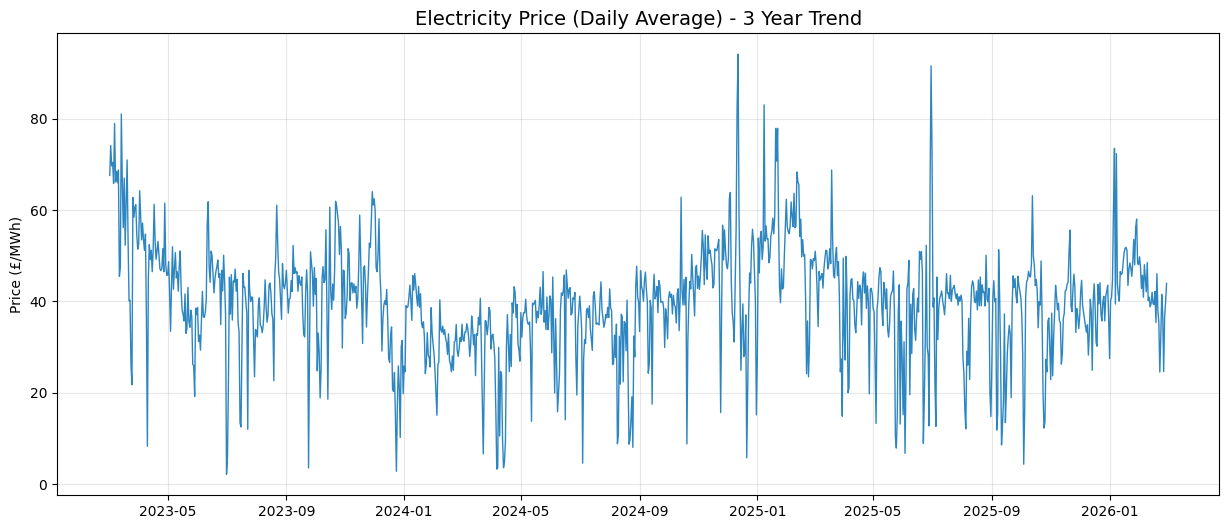

In [ ]:
df_daily = master_df['price'].resample('D').mean()

plt.figure(figsize=(14, 6))
plt.plot(df_daily.index, df_daily, color='#2E86C1', linewidth=1)
plt.title('Electricity Price (Daily Average) - 3 Year Trend', fontsize=14)
plt.ylabel('Price (£/MWh)')
plt.grid(True, alpha=0.25)
plt.show()

In [8]:
# 1. Define how each feature behaves when compressed into an hour
aggregation_rules = {
    'price': 'mean',        # Average price across the hour
    'volume': 'sum',        # Total volume traded in that hour
    'gas_price': 'mean',    # (Will remain unchanged since it's daily)
    'oil_price': 'mean',    # (Will remain unchanged)
    'london_temp': 'mean', 
    'london_clouds': 'mean',
    'north_sea_wind': 'mean',
    'Scottish Highlands_wind': 'mean',
    'Cornwall_clouds': 'mean'
}

# 2. Resample to 1-Hour ('1H') intervals
hourly_df = master_df.resample('1H').agg(aggregation_rules)

# 3. Recreate your time-based features based on the new hourly index
hourly_df['hour'] = hourly_df.index.hour
hourly_df['weekday'] = hourly_df.index.weekday
hourly_df['day_of_year'] = hourly_df.index.dayofyear

# Drop any incomplete trailing hours
hourly_df = hourly_df.dropna()

print(f"Old 30-min shape: {master_df.shape}")
print(f"New Hourly shape: {hourly_df.shape}")
print("\n✅ Hourly Master Dataset:")
print(hourly_df[['price', 'volume', 'north_sea_wind', 'hour']].head(3))

Old 30-min shape: (52560, 13)
New Hourly shape: (26281, 12)

✅ Hourly Master Dataset:
                             price   volume  north_sea_wind  hour
time                                                             
2023-03-02 00:00:00+00:00  56.4325  730.950           17.55     0
2023-03-02 01:00:00+00:00  58.5850  803.600           16.10     1
2023-03-02 02:00:00+00:00  57.7875  899.275           14.60     2


C:\Users\steph\AppData\Local\Temp\ipykernel_31632\3398121262.py:15: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  hourly_df = master_df.resample('1H').agg(aggregation_rules)


In [ ]:
y = hourly_df['price']

features = [
    'price',         # Raw price
    'volume',        # Raw volume
    'gas_price',     # Raw gas
    'oil_price',     # Raw oil
    # 'london_temp', 
    # 'london_clouds', 
    # 'north_sea_wind',
    # 'Scottish Highlands_wind',
    # 'Cornwall_clouds',
    'hour',
    'weekday',
    'day_of_year'
]
X = hourly_df[features].dropna()

In [ ]:
val_start_date = '2025-09-01'
test_start_date = '2026-01-01'


X_train = X.loc[X.index < val_start_date]
y_train = y.loc[y.index < val_start_date]

X_val = X.loc[(X.index >= val_start_date) & (X.index < test_start_date)]
y_val = y.loc[(y.index >= val_start_date) & (y.index < test_start_date)]

X_test = X.loc[X.index >= test_start_date]
y_test = y.loc[y.index >= test_start_date]

print(f"Train: {X_train.index.min()} to {X_train.index.max()}")
print(f"Val:   {X_val.index.min()} to {X_val.index.max()}")
print(f"Test:  {X_test.index.min()} to {X_test.index.max()}")

scaler = StandardScaler()


X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_val_scaled = pd.DataFrame(X_val_scaled, columns=X_val.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns)


Train: 2023-03-02 00:00:00+00:00 to 2025-08-31 23:00:00+00:00
Val:   2025-09-01 00:00:00+00:00 to 2025-12-31 23:00:00+00:00
Test:  2026-01-01 00:00:00+00:00 to 2026-03-01 00:00:00+00:00


In [ ]:

num_hours = len(grid_weather)
grid_size = 8  # 8x8 = 64 locations
num_vars = 3   # temp, wind, clouds

grid_values = grid_weather.drop(columns=['time'], errors='ignore').values


# Reshape to (Hours, 8 rows, 8 cols, 3 variables)
grid_array = grid_values.reshape(num_hours, grid_size, grid_size, num_vars)

# transpose to PyTorch CNN format: (Hours, Channels, Height, Width) -> (Hours, 3, 8, 8)
grid_array = grid_array.transpose(0, 3, 1, 2) 

print(f"Corrected Grid Shape: {grid_array.shape}") 

# 4. Split and standardize
grid_train = grid_array[:len(X_train)]
grid_val = grid_array[len(X_train):len(X_train)+len(X_val)]
grid_test = grid_array[len(X_train)+len(X_val):]

for v in range(num_vars):
    m = grid_train[:, v, :, :].mean()
    s = grid_train[:, v, :, :].std()
    
    grid_train[:, v, :, :] = (grid_train[:, v, :, :] - m) / s
    grid_val[:, v, :, :] = (grid_val[:, v, :, :] - m) / s
    grid_test[:, v, :, :] = (grid_test[:, v, :, :] - m) / s

Corrected Grid Shape: (35064, 3, 8, 8)


In [ ]:


# Scalar and  Grid inputs
def create_dual_sequences(X_scalar, X_grid, y, seq_length, forecast_horizon=24):
    scalar_seqs, grid_seqs, ys = [], [], []
    
    limit = len(X_scalar) - seq_length - forecast_horizon + 1
    
    for i in range(limit):
        #Scalar sequence (Price, Gas, etc.)
        scalar_seqs.append(X_scalar.iloc[i : (i + seq_length)].values)
        
        #rid sequence 
        grid_seqs.append(X_grid[i : (i + seq_length)])

        ys.append(y.iloc[i + seq_length + forecast_horizon - 1])
        
    return np.array(scalar_seqs), np.array(grid_seqs), np.array(ys)

seq_length = 168        # 7 days
forecast_horizon = 24   

X_train_scalar, X_train_grid, y_train_final = create_dual_sequences(X_train_scaled, grid_train, y_train, seq_length, forecast_horizon)
X_val_scalar, X_val_grid, y_val_final = create_dual_sequences(X_val_scaled, grid_val, y_val, seq_length, forecast_horizon)
X_test_scalar, X_test_grid, y_test_final = create_dual_sequences(X_test_scaled, grid_test, y_test, seq_length, forecast_horizon)

print(f"Scalar train shape: {X_train_scalar.shape}") 
print(f"Grid train shape: {X_train_grid.shape}")     


# Convert to Tensors
train_dataset = TensorDataset(
    torch.tensor(X_train_scalar, dtype=torch.float32),
    torch.tensor(X_train_grid, dtype=torch.float32),
    torch.tensor(y_train_final, dtype=torch.float32)
)
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)

val_dataset = TensorDataset(
    torch.tensor(X_val_scalar, dtype=torch.float32),
    torch.tensor(X_val_grid, dtype=torch.float32),
    torch.tensor(y_val_final, dtype=torch.float32)
)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False)

Scalar train shape: (21745, 168, 7)
Grid train shape: (21745, 168, 3, 8, 8)


In [112]:
y_test

time
2026-01-01 00:00:00+00:00    25.1700
2026-01-01 01:00:00+00:00    30.3000
2026-01-01 02:00:00+00:00    27.1125
2026-01-01 03:00:00+00:00    21.8700
2026-01-01 04:00:00+00:00    19.7875
                              ...   
2026-02-28 20:00:00+00:00    44.1975
2026-02-28 21:00:00+00:00    43.3175
2026-02-28 22:00:00+00:00    44.7850
2026-02-28 23:00:00+00:00    44.6975
2026-03-01 00:00:00+00:00    43.9500
Freq: h, Name: price, Length: 1417, dtype: float64

In [88]:
y_val

time
2025-09-01 00:00:00+00:00    13.3000
2025-09-01 01:00:00+00:00    12.1350
2025-09-01 02:00:00+00:00    10.6375
2025-09-01 03:00:00+00:00    18.1675
2025-09-01 04:00:00+00:00    29.1925
                              ...   
2025-12-31 19:00:00+00:00    39.9225
2025-12-31 20:00:00+00:00    33.5525
2025-12-31 21:00:00+00:00    29.2150
2025-12-31 22:00:00+00:00    25.7875
2025-12-31 23:00:00+00:00    26.0125
Freq: h, Name: price, Length: 2928, dtype: float64

In [87]:
y_val_final

array([39.525 , 39.9775, 40.2625, ..., 29.215 , 25.7875, 26.0125])

In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
import torch.optim as optim
import torch.nn.functional as F
from torch.distributions.studentT import StudentT
import torch.optim as optim


In [37]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
if device.type == 'cuda':
    print(f"GPU Name: {torch.cuda.get_device_name(0)}")

Using device: cuda
GPU Name: NVIDIA GeForce RTX 4060 Laptop GPU


In [ ]:


class StudentTHead(nn.Module):
    def __init__(self, in_features):
        super(StudentTHead, self).__init__()
        # outputs: df (degrees of freedom), loc (mean), scale (std dev)
        self.linear = nn.Linear(in_features, 3)

    def forward(self, x):
        params = self.linear(x)
        
        df = F.softplus(params[:, 0]) + 2.0 # df  > 2 for a defined variance
        
        # 2. Location (prediction )
        loc = params[:, 1]
        
        # 3. scale =  uncertainty>0
        scale = F.softplus(params[:, 2]) + 1e-6
        
        return df, loc, scale
    
# loss function student t
def student_t_loss(df, loc, scale, y_true):
    y_true = y_true.squeeze() 
    dist = StudentT(df=df, loc=loc, scale=scale)
    log_prob = dist.log_prob(y_true)
    return -log_prob.mean()

# Standart cos and sin encoding
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=5000):
        super(PositionalEncoding, self).__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        pe = pe.unsqueeze(0) # Shape: (1, max_len, d_model)
        self.register_buffer('pe', pe)

    def forward(self, x):
        x = x + self.pe[:, :x.size(1), :]
        return x


class ResBlock(nn.Module):
    def __init__(self, channels):
        super().__init__()
        self.conv1 = nn.Conv2d(channels, channels, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(channels)
        self.relu = nn.ReLU()
        self.conv2 = nn.Conv2d(channels, channels, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(channels)

    def forward(self, x):
        identity = x # Save the input
        out = self.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        out += identity # THE SHORTCUT: Add input back to the output
        return self.relu(out)
    
# class WeatherCNNEncoder(nn.Module):
#     def __init__(self, in_channels=3, out_features=32):
#         super(WeatherCNNEncoder, self).__init__()
#         # Removed MaxPool2d to prevent shrinking the 5x5 grid too fast
#         self.conv_block = nn.Sequential(
#             nn.Conv2d(in_channels, 16, kernel_size=3, padding=1),
#             nn.ReLU(),
#             nn.MaxPool2d(2),
#             nn.Conv2d(16, 32, kernel_size=3, padding=1),
#             nn.BatchNorm2d(32),
#             nn.ReLU(),
#             nn.AdaptiveAvgPool2d((1, 1)), # Global pool to a single vector
#             nn.Flatten()
#         )
#         self.fc = nn.Linear(32, out_features)

#     def forward(self, x):
#         # x shape expected: (Batch * Seq, 3, 5, 5)
#         x = self.conv_block(x)
#         return self.fc(x)
class DeeperWeatherCNN(nn.Module):
    def __init__(self, in_channels=3, out_features=32):
        super().__init__()
        # projection to a higher channel dimension
        self.initial = nn.Sequential(
            nn.Conv2d(in_channels, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU()
        )
        #  Residual Blocks
        self.layer1 = ResBlock(32)
        self.layer2 = ResBlock(32)
        # Global pooling to turn the 8x8 to 1x1
        self.pool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Linear(32, out_features)

    def forward(self, x):
        # x: (B*S, 3, 8, 8)
        x = self.initial(x) # (B*S, 32, 8, 8)
        x = self.layer1(x)  # (B*S, 32, 8, 8)
        x = self.layer2(x)  # (B*S, 32, 8, 8)
        x = self.pool(x)    # (B*S, 32, 1, 1)
        x = torch.flatten(x, 1) # (B*S, 32)
        return self.fc(x) 

class SpatioTemporalTransformer(nn.Module):
    def __init__(self, scalar_features, cnn_out=32, d_model=64, num_heads=4, num_layers=4, dropout=0.1):
        super().__init__()
        self.weather_cnn = DeeperWeatherCNN(out_features=cnn_out)
        
        # Concatenate scalar features with CNN features
        self.input_proj = nn.Linear(scalar_features + cnn_out, d_model)
        self.pos_encoder = PositionalEncoding(d_model)
        
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model, 
            nhead=num_heads, 
            dim_feedforward=d_model * 2,
            dropout=dropout,
            batch_first=True
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        # self.prob_head = StudentTHead(d_model)
        self.prob_head = StudentTHead(d_model * 2)

    def forward(self, scalar_data, grid_weather):
        # process Grid Weather
        batch_size, seq_len = grid_weather.shape[0], grid_weather.shape[1]
        
        # Flatten time into batch dimension for CNN: (B, S, C, H, W) -> (B*S, C, H, W)
        grid_flat = grid_weather.view(-1, 3, 8, 8) 
        
        weather_features = self.weather_cnn(grid_flat) # Output: (B*S, 32)
        
        # reshape back to sequence: (B, S, 32)
        weather_seq = weather_features.view(batch_size, seq_len, -1)
        
        #  Concatenate with Scalar features: (B, S, scalar_features + 32)
        combined = torch.cat([scalar_data, weather_seq], dim=-1)
        
        x = self.input_proj(combined)
        x = self.pos_encoder(x)
        x = self.transformer(x)
        
        # Output Prediction (using only the last time step) 
        # return self.prob_head(x[:, -1, :])
        # x_avg = x.mean(dim=1) 
        # return self.prob_head(x_avg)

        # last_step = x[:, -1, :]
        # avg_step = x.mean(dim=1)
        # combined = torch.cat([last_step, avg_step], dim=-1)

        last_step = x[:, -1, :]
        avg_step = x.mean(dim=1)
        combined = torch.cat([last_step, avg_step], dim=-1)    
        return self.prob_head(combined)

In [97]:
X_train_scalar.shape[2]

7

In [ ]:


# 1. Initialize the new SpatioTemporal model
num_scalar_features = X_train_scalar.shape[2]

model_custom_head = SpatioTemporalTransformer(
    scalar_features=num_scalar_features, 
    cnn_out=64,          # Output size from the 8x8 CNN
    d_model=84,          # Transformer hidden dimension
    num_heads=12,         # Number of attention heads 
    num_layers=4,        # Number of Transformer layers 
    dropout=0.3          # Dropout probability 
).to(device)

#  optimizer Adam
optimizer = optim.AdamW(model_custom_head.parameters(), lr=3e-4) #LR
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)
epochs = 3  #manually stoped early based on previous training
train_losses = []
val_losses = []

print("Starting Probabilistic Spatio-Temporal Training...")
for epoch in range(epochs):

    model_custom_head.train() 
    epoch_train_loss = 0.0
    
    #  Unpack 3 items from the multi-input DataLoader
    for batch_scalar, batch_grid, batch_y in train_loader:
        
        # Move 3 tensors to the GPU
        batch_scalar = batch_scalar.to(device)
        batch_grid = batch_grid.to(device)
        batch_y = batch_y.to(device)
        
        optimizer.zero_grad()
        
        df, loc, scale = model_custom_head(batch_scalar, batch_grid) 
        
        loss = student_t_loss(df, loc, scale, batch_y)
        loss.backward()
        
        # Gradient clipping 
        torch.nn.utils.clip_grad_norm_(model_custom_head.parameters(), max_norm=1.0)
        optimizer.step()
        
        epoch_train_loss += loss.item() * batch_scalar.size(0)
        
    avg_train_loss = epoch_train_loss / len(train_loader.dataset)
    train_losses.append(avg_train_loss)
    

    model_custom_head.eval() 
    epoch_val_loss = 0.0
    
    with torch.no_grad(): 
        for batch_scalar, batch_grid, batch_y in val_loader:
            
            batch_scalar = batch_scalar.to(device)
            batch_grid = batch_grid.to(device)
            batch_y = batch_y.to(device)
            
            # Pass both inputs
            df, loc, scale = model_custom_head(batch_scalar, batch_grid)
            

            loss = student_t_loss(df, loc, scale, batch_y)
            epoch_val_loss += loss.item() * batch_scalar.size(0)
            
    avg_val_loss = epoch_val_loss / len(val_loader.dataset)
    scheduler.step(avg_val_loss) # Scheduler updates based on validation 
    val_losses.append(avg_val_loss)
    
    print(f"Epoch {epoch+1}/{epochs} | Train NLL Loss: {avg_train_loss:.4f} | Val NLL Loss: {avg_val_loss:.4f}")

Starting Probabilistic Spatio-Temporal Training...
Epoch 1/3 | Train NLL Loss: 5.6144 | Val NLL Loss: 4.2463
Epoch 2/3 | Train NLL Loss: 4.1235 | Val NLL Loss: 3.9243
Epoch 3/3 | Train NLL Loss: 3.8526 | Val NLL Loss: 3.8107


In [ ]:
# save model
PATH = "transformer_model_8_8_grid.pth"

torch.save(model_custom_head.state_dict(), PATH)

In [ ]:
# evalatuion on val set
model_custom_head.eval()
val_predictions = []
val_uncertainties = [] #

with torch.no_grad():
    for batch_scalar, batch_grid, _ in val_loader:
        
        batch_scalar = batch_scalar.to(device)
        batch_grid = batch_grid.to(device)
        

        df, loc, scale = model_custom_head(batch_scalar, batch_grid)
        
        # Move predictions back to CPU and convert to numpy
        val_predictions.append(loc.cpu().numpy())
        val_uncertainties.append(scale.cpu().numpy())

# Flatten the lists 1D numpy arrays
val_predictions = np.concatenate(val_predictions).flatten()
val_uncertainties = np.concatenate(val_uncertainties).flatten()


rmse = np.sqrt(mean_squared_error(y_val_final, val_predictions))
mae = mean_absolute_error(y_val_final, val_predictions)

print(f"Validation RMSE: {rmse:.4f}")
print(f"Validation MAE: {mae:.4f}")

#Validation RMSE: 11.9617
# Validation MAE: 7.9699
# model_custom_head = SpatioTemporalTransformer(
#     scalar_features=num_scalar_features, 
#     cnn_out=32,          # Output size from the 5x5 CNN
#     d_model=64,          # Transformer hidden dimension
#     num_heads=8,         # Number of attention heads [cite: 96]
#     num_layers=4,        # Number of Transformer layers [cite: 97]
#     dropout=0.3          # Dropout probability [cite: 99]
# ).to(device)

Validation RMSE: 12.5725
Validation MAE: 8.7711


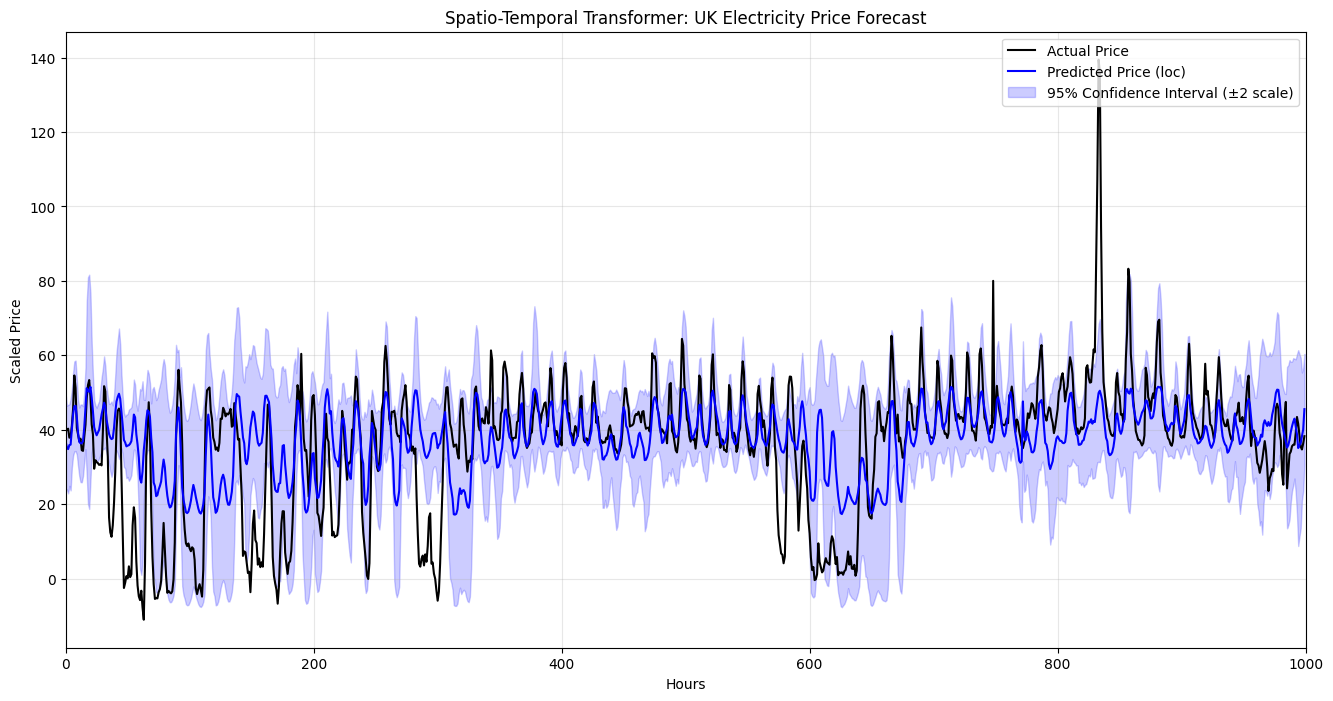

In [ ]:


plt.figure(figsize=(16, 8))


plot_limit = 250
x_axis = np.arange(plot_limit)

#  Actual vs Predicted (Mean)
sns.lineplot(x=x_axis, y=y_val_final[:plot_limit], label='Actual Price', color='black', linewidth=1.5)
sns.lineplot(x=x_axis, y=val_predictions[:plot_limit], label='Predicted Price (loc)', color='blue', linewidth=1.5)


upper_bound = val_predictions[:plot_limit] + (2 * val_uncertainties[:plot_limit])
lower_bound = val_predictions[:plot_limit] - (2 * val_uncertainties[:plot_limit])

plt.fill_between(
    x_axis, 
    lower_bound, 
    upper_bound, 
    color='blue', 
    alpha=0.2, 
    label='95% Confidence Interval (±2 scale)'
)

plt.title("Spatio-Temporal Transformer: UK Electricity Price Forecast")
plt.ylabel("Scaled Price")
plt.xlabel("Hours")
plt.xlim(0, plot_limit)
plt.legend(loc='upper right')
plt.grid(True, alpha=0.3)
plt.show()

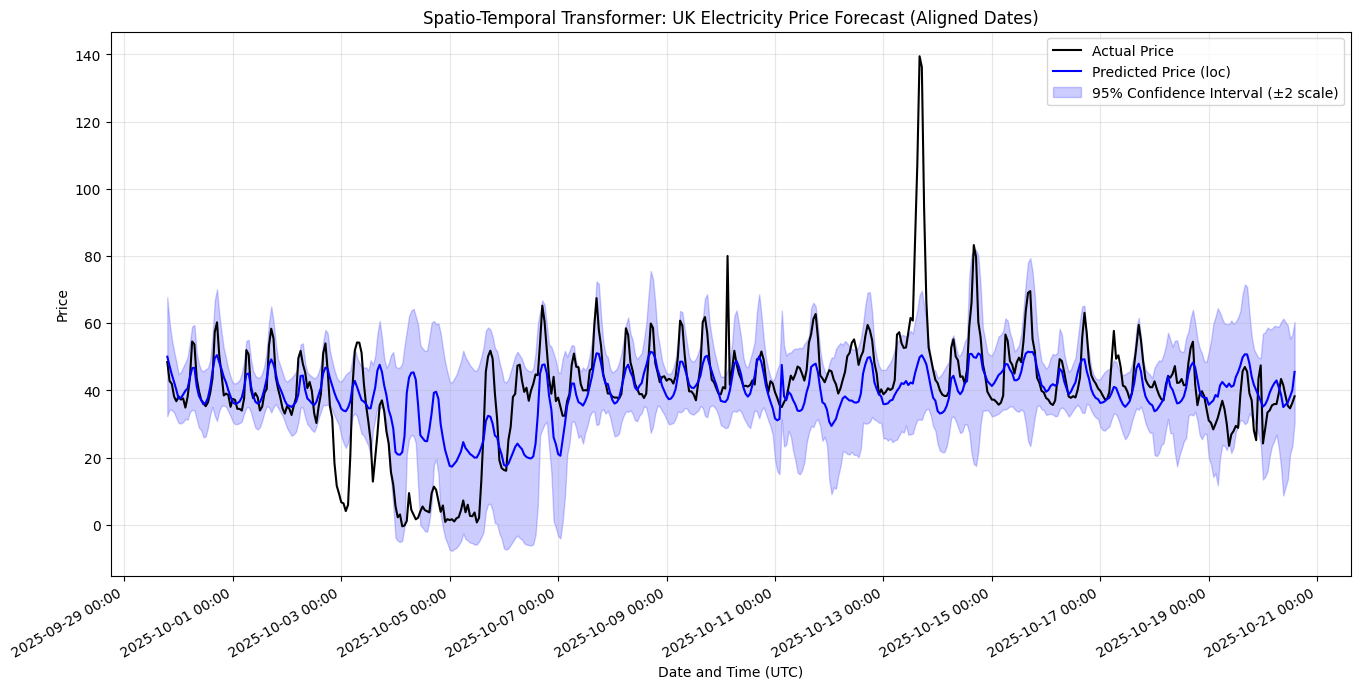

In [103]:
import matplotlib.dates as mdates
# The offset is the sum of your lookback and forecast horizon minus 1
# This should match the slicing logic we used to keep targets aligned
offset = seq_length + forecast_horizon - 1

# Extract the slice of the index from your original X_val (before scaling) 
# that matches the targets we just predicted
val_dates = X_val.index[offset : offset + len(y_val_final)]
plt.figure(figsize=(16, 8))

# Limit the plot to the first 1000 hours for visibility
plot_limit_start = 500
plot_limit_end = 1000

x_dates = val_dates[plot_limit_start:plot_limit_end]

# Plot Actual vs Predicted (Mean) using the dates
sns.lineplot(x=x_dates, y=y_val_final[plot_limit_start:plot_limit_end], label='Actual Price', color='black', linewidth=1.5)
sns.lineplot(x=x_dates, y=val_predictions[plot_limit_start:plot_limit_end], label='Predicted Price (loc)', color='blue', linewidth=1.5)

# Calculate bounds for the Confidence Interval
upper_bound = val_predictions[plot_limit_start:plot_limit_end] + (2 * val_uncertainties[plot_limit_start:plot_limit_end])
lower_bound = val_predictions[plot_limit_start:plot_limit_end] - (2 * val_uncertainties[plot_limit_start:plot_limit_end])

plt.fill_between(
    x_dates, 
    lower_bound, 
    upper_bound, 
    color='blue', 
    alpha=0.2, 
    label='95% Confidence Interval (±2 scale)'
)

# --- Improve Date Formatting on X-Axis ---
# This ensures the dates are slanted and readable
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d %H:%M'))
plt.gca().xaxis.set_major_locator(mdates.DayLocator(interval=2)) # Label every 2 days
plt.gcf().autofmt_xdate() # Auto-rotate dates

plt.title("Spatio-Temporal Transformer: UK Electricity Price Forecast (Aligned Dates)")
plt.ylabel("Price")
plt.xlabel("Date and Time (UTC)")
plt.legend(loc='upper right')
plt.grid(True, alpha=0.3)
plt.show()

## test set

In [116]:

test_dataset = TensorDataset(
    torch.tensor(X_test_scalar, dtype=torch.float32),
    torch.tensor(X_test_grid, dtype=torch.float32),
    torch.tensor(y_test_final, dtype=torch.float32)
)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

In [ ]:
model_custom_head.eval()

test_predictions = []
test_uncertainties = [] 

with torch.no_grad():
    for batch_scalar, batch_grid, _ in test_loader:
        
        batch_scalar = batch_scalar.to(device)
        batch_grid = batch_grid.to(device)
        
        df, loc, scale = model_custom_head(batch_scalar, batch_grid)
        

        test_predictions.append(loc.cpu().numpy())
        test_uncertainties.append(scale.cpu().numpy())

test_predictions = np.concatenate(test_predictions).flatten()
test_uncertainties = np.concatenate(test_uncertainties).flatten()



In [138]:
model_custom_head.eval()
test_dfs = []         # NEW: Keep track of degrees of freedom
test_predictions = [] 
test_uncertainties = [] 

with torch.no_grad():
    for batch_scalar, batch_grid, _ in test_loader:
        
        batch_scalar = batch_scalar.to(device)
        batch_grid = batch_grid.to(device)
        
        df, loc, scale = model_custom_head(batch_scalar, batch_grid)
        
        # Save all three parameters
        test_dfs.append(df.cpu().numpy())
        test_predictions.append(loc.cpu().numpy())
        test_uncertainties.append(scale.cpu().numpy())

# Flatten the lists of batches into single 1D numpy arrays
test_dfs = np.concatenate(test_dfs).flatten()
test_predictions = np.concatenate(test_predictions).flatten()
test_uncertainties = np.concatenate(test_uncertainties).flatten()

In [ ]:
from scipy import stats

lower_bound, upper_bound = stats.t.interval(
    confidence=0.95, 
    df=test_dfs, 
    loc=test_predictions, 
    scale=test_uncertainties
)

rmse = np.sqrt(mean_squared_error(y_test_final, test_predictions))
mae = mean_absolute_error(y_test_final, test_predictions)

# Cboolean  True if the actual value is between the bounds, False otherwise
inside_interval = (y_test_final >= lower_bound) & (y_test_final <= upper_bound)
coverage_percentage = inside_interval.mean() * 100

print(f"Test RMSE: {rmse:.4f}")
print(f"Test MAE: {mae:.4f}")
print(f"95% Interval Coverage: {coverage_percentage:.2f}%")

Test RMSE: 7.6882
Test MAE: 5.4891
95% Interval Coverage: 99.02%


In [118]:
test_predictions.shape

(1226,)

In [119]:
y_test_final.shape

(1226,)

In [120]:
rmse = np.sqrt(mean_squared_error(y_test_final, test_predictions))
mae = mean_absolute_error(y_test_final, test_predictions)

print(f"testidation RMSE: {rmse:.4f}")
print(f"testidation MAE: {mae:.4f}")

testidation RMSE: 7.6882
testidation MAE: 5.4891


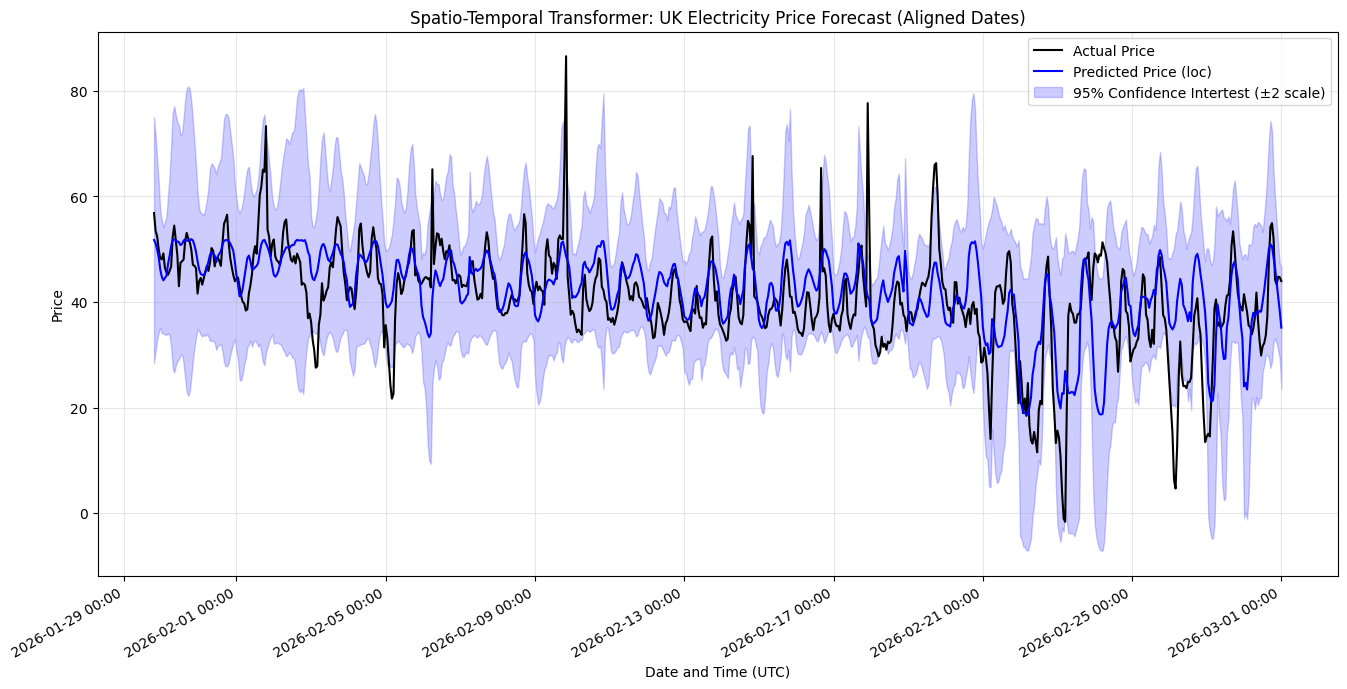

In [ ]:


offset = seq_length + forecast_horizon - 1


test_dates = X_test.index[offset : offset + len(y_test_final)]
plt.figure(figsize=(16, 8))

plot_limit_start = 500
plot_limit_end = 1500

x_dates = test_dates[plot_limit_start:plot_limit_end]

sns.lineplot(x=x_dates, y=y_test_final[plot_limit_start:plot_limit_end], label='Actual Price', color='black', linewidth=1.5)
sns.lineplot(x=x_dates, y=test_predictions[plot_limit_start:plot_limit_end], label='Predicted Price (loc)', color='blue', linewidth=1.5)

upper_bound = test_predictions[plot_limit_start:plot_limit_end] + (2 * test_uncertainties[plot_limit_start:plot_limit_end])
lower_bound = test_predictions[plot_limit_start:plot_limit_end] - (2 * test_uncertainties[plot_limit_start:plot_limit_end])

plt.fill_between(
    x_dates, 
    lower_bound, 
    upper_bound, 
    color='blue', 
    alpha=0.2, 
    label='95% Confidence Intertest (±2 scale)'
)


plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d %H:%M'))
# plt.gca().xaxis.set_major_locator(mdates.DayLocator(intertest=2)) # Label every 2 days
plt.gcf().autofmt_xdate() # Auto-rotate dates

plt.title("Spatio-Temporal Transformer: UK Electricity Price Forecast (Aligned Dates)")
plt.ylabel("Price")
plt.xlabel("Date and Time (UTC)")
plt.legend(loc='upper right')
plt.grid(True, alpha=0.3)
plt.show()

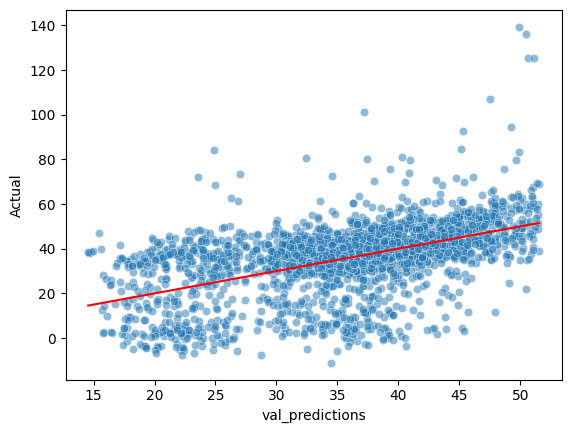

In [96]:
sns.scatterplot(x=val_predictions,y=y_val_final,alpha=0.5)
plt.xlabel('val_predictions')
plt.ylabel('Actual')
identity_line = np.linspace(max(min(val_predictions), min(y_val_final)),
                            min(max(val_predictions), max(y_val_final)))
plt.plot(identity_line, identity_line, color='red')
plt.show()